# NER на FactRuEval-2016

В этой работе я дообучаю трансформерную модель для задачи NER и сравниваю несколько вариантов обучения.

Что есть в ноутбуке:

1. загрузка `gusevski/factrueval2016`;
2. приведение разметки к BIO-формату;
3. токенизация и выравнивание меток после разбиения слов на subword-токены;
4. замер качества базовой модели до NER-обучения;
5. fine-tuning RuBERT на NER;
6. дополнительное MLM-дообучение с whole word masking, после него ещё один NER fine-tuning;
7. сравнение результатов и короткие выводы.

Почему я взял именно этот вариант:

- HF-версия FactRuEval уже лежит в удобном формате `tokens` + `ner_tags`, поэтому не нужно отдельно парсить исходные файлы из GitHub.
- В качестве энкодера использую `DeepPavlov/rubert-base-cased`, потому что это нормальный базовый RuBERT для русского языка и он подходит под token classification.
- Для улучшения качества проверяю MLM + Whole Word Mask.

## 0. Установка зависимостей

Ноутбук я планирую запускать локально на CUDA на своей видеокарте.

In [8]:
# %pip install -U \
#     "transformers>=4.44" \
#     "datasets>=2.20" \
#     "evaluate>=0.4" \
#     "accelerate>=0.33" \
#     seqeval \
#     pandas \
#     numpy \
#     scikit-learn \
#     matplotlib \
#     ipywidgets

## 1. Импорты и основные настройки

Здесь задаю seed, модель, длину последовательности и базовые параметры обучения.

In [32]:
import os
import re
import gc
import json
import math
import random
import inspect
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from datasets import load_dataset, Dataset, DatasetDict
import evaluate

from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    AutoModelForMaskedLM,
    DataCollatorForTokenClassification,
    DataCollatorForWholeWordMask,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed,
)

os.environ["TOKENIZERS_PARALLELISM"] = "false"

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Базовый RuBERT для русского языка.
BASE_MODEL = "DeepPavlov/rubert-base-cased"
DATASET_ID = "gusevski/factrueval2016"

# Основные настройки запуска.
MAX_LENGTH = 256
LABEL_ALL_TOKENS = False  # loss считаю только по первому subtoken слова
FAST_DEV_RUN = False      # True — быстро проверить код на маленькой выборке
OUTPUT_ROOT = Path("outputs_factrueval_ner")
OUTPUT_ROOT.mkdir(exist_ok=True)

# Если не хватит памяти, сначала уменьшаю train batch size.
NER_EPOCHS = 1 if FAST_DEV_RUN else 5
MLM_EPOCHS = 1 if FAST_DEV_RUN else 3
TRAIN_BATCH_SIZE = 8 if FAST_DEV_RUN else 16
EVAL_BATCH_SIZE = 16 if FAST_DEV_RUN else 32
GRAD_ACCUM = 1

if torch.cuda.is_available():
    device_name = torch.cuda.get_device_name(0)
    capability = torch.cuda.get_device_capability(0)
    torch.set_float32_matmul_precision("high")
    print(f"CUDA: {device_name}, compute capability={capability}")
else:
    print("CUDA не найдена. Ноутбук запустится на CPU, но для сдачи лучше обучать на GPU.")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CUDA: NVIDIA GeForce RTX 5070 Ti, compute capability=(12, 0)


In [33]:
def precision_kwargs():
    """Подбираю mixed precision по доступной CUDA-карте."""
    if not torch.cuda.is_available():
        return {"fp16": False, "bf16": False}
    major, _ = torch.cuda.get_device_capability(0)
    if major >= 8:
        return {"fp16": False, "bf16": True}
    return {"fp16": True, "bf16": False}

MIXED_PRECISION = precision_kwargs()
MIXED_PRECISION

{'fp16': False, 'bf16': True}

## 2. Загрузка и подготовка датасета

В HF-версии датасет приходит не сразу в виде отдельных примеров, а через поле `data`. Поэтому ниже есть небольшая функция для приведения корпуса к обычному виду: один пример — это список токенов и список NER-меток такой же длины.

In [34]:
raw = load_dataset(DATASET_ID)
raw

Repo card metadata block was not found. Setting CardData to empty.


DatasetDict({
    train: Dataset({
        features: ['data'],
        num_rows: 1
    })
    validation: Dataset({
        features: ['data'],
        num_rows: 1
    })
    test: Dataset({
        features: ['data'],
        num_rows: 1
    })
})

In [35]:
raw['train'][0]

{'data': [{'id': 0,
   'tokens': ['"',
    'Если',
    'Миронов',
    'занял',
    'столь',
    'оппозиционную',
    'позицию',
    ',',
    'то',
    'мне',
    'представляется',
    ',',
    'что',
    'для',
    'него',
    'было',
    'бы',
    'порядочным',
    'и',
    'правильным',
    'уйти',
    'в',
    'отставку',
    'с',
    'занимаемого',
    'им',
    'поста',
    ',',
    'поста',
    ',',
    'который',
    'предоставлен',
    'ему',
    'сегодня',
    '"',
    'Единой',
    'Россией',
    "''",
    'и',
    'никем',
    'больше',
    "''",
    ',',
    '-',
    'заключает',
    'Исаев',
    '.'],
   'length': 47,
   'ner_tags_str': ['O',
    'O',
    'B-PER',
    'O',
    'O',
    'O',
    'O',
    'O',
    'O',
    'O',
    'O',
    'O',
    'O',
    'O',
    'O',
    'O',
    'O',
    'O',
    'O',
    'O',
    'O',
    'O',
    'O',
    'O',
    'O',
    'O',
    'O',
    'O',
    'O',
    'O',
    'O',
    'O',
    'O',
    'O',
    'O',
    'B-ORG',
    'I-ORG',


In [36]:
def _records_from_data_field(data_field):
    """Достаёт примеры из поля data, если датасет пришёл вложенным."""
    if data_field is None:
        return []
    if isinstance(data_field, list):
        return data_field
    if isinstance(data_field, dict):
        # Встречается вариант dict-of-lists вместо list-of-dicts.
        if data_field and all(isinstance(v, list) for v in data_field.values()):
            keys = list(data_field.keys())
            n = len(data_field[keys[0]])
            return [{k: data_field[k][i] for k in keys} for i in range(n)]
        return [data_field]
    return []


def _choose_ner_tags(record):
    """Беру строковые BIO-метки, если они есть; числовые ner_tags оставляю как fallback."""
    if "ner_tags_str" in record and record["ner_tags_str"] is not None:
        return record["ner_tags_str"]
    return record.get("ner_tags")


def flatten_factrueval_dataset(raw_ds):
    """Делаю из исходного объекта обычный DatasetDict с tokens и ner_tags."""
    out = {}
    for split_name, split_ds in raw_ds.items():
        if "data" not in split_ds.column_names:
            out[split_name] = split_ds
            continue

        records = []
        for row in split_ds:
            records.extend(_records_from_data_field(row.get("data")))

        clean_records = []
        for i, r in enumerate(records):
            if not isinstance(r, dict):
                continue
            if "tokens" not in r:
                continue
            tokens = [str(x) for x in r["tokens"]]
            raw_tags = _choose_ner_tags(r)
            if raw_tags is None:
                continue
            tags = list(raw_tags)
            if len(tokens) != len(tags):
                continue
            clean_records.append({
                "id": str(r.get("id", f"{split_name}_{i}")),
                "tokens": tokens,
                "ner_tags": tags,
            })

        out[split_name] = Dataset.from_list(clean_records)

    # Стандартизируем имя validation, если вдруг split называется dev.
    if "validation" not in out and "dev" in out:
        out["validation"] = out.pop("dev")

    return DatasetDict(out)


ds = flatten_factrueval_dataset(raw)
ds

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 7746
    })
    validation: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 2582
    })
    test: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 2582
    })
})

In [38]:
# Смотрю, что получилось после подготовки.
for split in ds:
    print(split, len(ds[split]), ds[split].column_names)

print("\nПример:")
example = ds["train"][0]
print(example["tokens"][:30])
print(example["ner_tags"][:30])

train 7746 ['id', 'tokens', 'ner_tags']
validation 2582 ['id', 'tokens', 'ner_tags']
test 2582 ['id', 'tokens', 'ner_tags']

Пример:
['"', 'Если', 'Миронов', 'занял', 'столь', 'оппозиционную', 'позицию', ',', 'то', 'мне', 'представляется', ',', 'что', 'для', 'него', 'было', 'бы', 'порядочным', 'и', 'правильным', 'уйти', 'в', 'отставку', 'с', 'занимаемого', 'им', 'поста', ',', 'поста', ',']
['O', 'O', 'B-PER', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']


In [39]:
print("\nПример:")
example = ds["train"][1]
print(example["tokens"][:30])
print(example["ner_tags"][:30])


Пример:
['Источник', '"', 'Ъ', "''", 'в', 'руководстве', 'столичной', 'мэрии', 'считает', 'маловероятным', ',', 'что', 'господина', 'Митволя', 'назначили', 'с', 'целью', '"', 'укрепления', 'границ', 'с', 'Подмосковьем', "''", '.']
['O', 'O', 'B-ORG', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-PER', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-LOC', 'O', 'O']


In [40]:
def get_feature_label_names(dataset_dict):
    """Пытаюсь достать названия классов, если они есть в features."""
    try:
        feat = dataset_dict["train"].features["ner_tags"].feature
        if hasattr(feat, "names") and feat.names:
            return list(feat.names)
    except Exception:
        pass
    return None

RAW_LABEL_NAMES = get_feature_label_names(ds)
RAW_LABEL_NAMES

In [41]:
def tag_to_str(tag):
    """Привожу метку к строковому виду."""
    if isinstance(tag, str):
        return tag
    if RAW_LABEL_NAMES is not None:
        return RAW_LABEL_NAMES[int(tag)]
    return str(tag)


def normalize_tags_to_bio(raw_tags):
    """
    Привожу метки к BIO. Если BIO уже есть, почти ничего не меняется.
    Если метки заданы просто как PER/ORG/LOC, восстанавливаю B-/I- по соседним токенам.
    """
    tags = [tag_to_str(t) for t in raw_tags]
    out = []
    prev_entity = "O"

    for tag in tags:
        tag = str(tag)
        if tag in {"O", "0", "None", "NONE", "null", ""}:
            out.append("O")
            prev_entity = "O"
            continue

        # На всякий случай привожу разделитель к одному виду.
        tag = tag.replace("_", "-")

        if tag.startswith("B-") or tag.startswith("I-"):
            prefix, ent = tag.split("-", 1)
            ent = ent.upper()
            out.append(f"{prefix}-{ent}")
            prev_entity = ent if prefix in {"B", "I"} else "O"
            continue

        # Вариант без BIO-префикса.
        ent = tag.upper()
        prefix = "I" if prev_entity == ent else "B"
        out.append(f"{prefix}-{ent}")
        prev_entity = ent

    return out


def normalize_example(example):
    return {
        "tokens": [str(t) for t in example["tokens"]],
        "ner_tags": normalize_tags_to_bio(example["ner_tags"]),
    }


ds = ds.map(normalize_example)

if FAST_DEV_RUN:
    ds = DatasetDict({
        "train": ds["train"].select(range(min(300, len(ds["train"])))),
        "validation": ds["validation"].select(range(min(100, len(ds["validation"])))),
        "test": ds["test"].select(range(min(100, len(ds["test"])))),
    })

ds

Map:   0%|          | 0/7746 [00:00<?, ? examples/s]

Map:   0%|          | 0/2582 [00:00<?, ? examples/s]

Map:   0%|          | 0/2582 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 7746
    })
    validation: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 2582
    })
    test: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 2582
    })
})

In [42]:
def collect_label_list(dataset_dict):
    labels = set()
    for split in dataset_dict:
        for tags in dataset_dict[split]["ner_tags"]:
            labels.update(tags)

    entity_types = sorted({x.split("-", 1)[1] for x in labels if x != "O" and "-" in x})
    # Сначала ставлю основные типы, чтобы порядок был понятнее.
    preferred = ["PER", "LOC", "ORG"]
    entity_types = [x for x in preferred if x in entity_types] + [x for x in entity_types if x not in preferred]

    label_list = ["O"]
    for ent in entity_types:
        label_list.extend([f"B-{ent}", f"I-{ent}"])
    return label_list

label_list = collect_label_list(ds)
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for label, i in label2id.items()}

print(label_list)
print("num_labels:", len(label_list))

['O', 'B-PER', 'I-PER', 'B-LOC', 'I-LOC', 'B-ORG', 'I-ORG']
num_labels: 7


In [43]:
label2id

{'O': 0,
 'B-PER': 1,
 'I-PER': 2,
 'B-LOC': 3,
 'I-LOC': 4,
 'B-ORG': 5,
 'I-ORG': 6}

In [44]:
def dataset_stats(dataset_dict):
    rows = []
    for split in dataset_dict:
        n_tokens = [len(x) for x in dataset_dict[split]["tokens"]]
        entity_counter = Counter()
        token_tag_counter = Counter()
        for tags in dataset_dict[split]["ner_tags"]:
            token_tag_counter.update(tags)
            # Количество сущностей приближённо считаю по B-тегам.
            for tag in tags:
                if tag.startswith("B-"):
                    entity_counter[tag[2:]] += 1
        rows.append({
            "split": split,
            "n_examples": len(dataset_dict[split]),
            "avg_tokens": round(float(np.mean(n_tokens)), 2),
            "max_tokens": int(np.max(n_tokens)),
            "entities": dict(entity_counter),
            "token_tags": dict(token_tag_counter),
        })
    return pd.DataFrame(rows)

stats_df = dataset_stats(ds)
stats_df

,split,n_examples,avg_tokens,max_tokens,entities,token_tags
0,train,7746,20.23,103,"{'PER': 6359, 'ORG': 5084, 'LOC': 4335}","{'O': 132788, 'B-PER': 6359, 'B-ORG': 5084, 'I..."
1,validation,2582,19.82,207,"{'ORG': 1629, 'LOC': 1394, 'PER': 2110}","{'O': 43239, 'B-ORG': 1629, 'I-ORG': 1186, 'B-..."
2,test,2582,20.54,222,"{'ORG': 1734, 'LOC': 1508, 'PER': 2150}","{'O': 44847, 'B-ORG': 1734, 'I-ORG': 1090, 'B-..."


## 3. Токенизация и выравнивание меток

NER-разметка дана на уровне слов. BERT-токенизатор может разбить одно слово на несколько частей, поэтому метки нужно аккуратно перенести на subword-токены.

Я использую стандартный вариант:

- специальные токены не участвуют в loss и получают `-100`;
- если слово разбилось на несколько частей, метка ставится только первой части;
- остальные части слова тоже получают `-100`.

Так модель учится по словам, а не начинает переучиваться на технические куски токенизации.

In [45]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, use_fast=True)
assert tokenizer.is_fast, "Нужен fast-tokenizer, потому что используется word_ids() для выравнивания меток."

data_collator_ner = DataCollatorForTokenClassification(tokenizer=tokenizer, pad_to_multiple_of=8)
print(type(tokenizer), tokenizer.model_max_length)

<class 'transformers.models.bert.tokenization_bert.BertTokenizer'> 1000000000000000019884624838656


In [46]:
def convert_tags_to_ids(tags):
    return [label2id[t] for t in tags]


def b_to_i_label_id(label_id):
    label = id2label[label_id]
    if label.startswith("B-"):
        return label2id.get("I-" + label[2:], label_id)
    return label_id


def tokenize_and_align_labels(examples):
    tokenized = tokenizer(
        examples["tokens"],
        is_split_into_words=True,
        truncation=True,
        max_length=MAX_LENGTH,
    )

    aligned_labels = []
    for i, tags in enumerate(examples["ner_tags"]):
        word_ids = tokenized.word_ids(batch_index=i)
        tag_ids = convert_tags_to_ids(tags)
        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(tag_ids[word_idx])
            else:
                if LABEL_ALL_TOKENS:
                    label_ids.append(b_to_i_label_id(tag_ids[word_idx]))
                else:
                    label_ids.append(-100)
            previous_word_idx = word_idx

        aligned_labels.append(label_ids)

    tokenized["labels"] = aligned_labels
    return tokenized


tokenized_ds = ds.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=ds["train"].column_names,
)

tokenized_ds

Map:   0%|          | 0/7746 [00:00<?, ? examples/s]

Map:   0%|          | 0/2582 [00:00<?, ? examples/s]

Map:   0%|          | 0/2582 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 7746
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 2582
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 2582
    })
})

In [47]:
# Проверка одного примера после токенизации.
i = 0
sample = tokenized_ds["train"][i]
toks = tokenizer.convert_ids_to_tokens(sample["input_ids"])
labs = [id2label[x] if x != -100 else "IGN" for x in sample["labels"]]
pd.DataFrame({"token": toks, "label": labs}).head(40)

,token,label
0,[CLS],IGN
1,"""",O
2,Если,O
3,Миронов,B-PER
4,занял,O
5,столь,O
6,оппозиционную,O
7,позицию,O
8,",",O
9,то,O


## 4. Метрики и вспомогательные функции

Для оценки использую `seqeval`. Главная метрика — entity-level F1: сущность считается найденной правильно только если совпали её тип и границы. Accuracy оставляю для справки, но как основную метрику её брать не стоит, потому что в NER много токенов класса `O`.

In [48]:
seqeval = evaluate.load("seqeval")


def predictions_to_labels(logits_or_preds, labels):
    """Перевожу предсказания и ответы в формат, который ждёт seqeval."""
    if logits_or_preds.ndim == 3:
        preds = np.argmax(logits_or_preds, axis=-1)
    else:
        preds = logits_or_preds

    true_predictions = []
    true_labels = []

    for pred_seq, label_seq in zip(preds, labels):
        seq_preds = []
        seq_labels = []
        for pred_id, label_id in zip(pred_seq, label_seq):
            if label_id == -100:
                continue
            seq_preds.append(id2label[int(pred_id)])
            seq_labels.append(id2label[int(label_id)])
        true_predictions.append(seq_preds)
        true_labels.append(seq_labels)

    return true_predictions, true_labels


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    true_predictions, true_labels = predictions_to_labels(logits, labels)
    results = seqeval.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }


def clean_metric_dict(metrics):
    """Оставляю числовые метрики без префиксов Trainer."""
    out = {}
    for k, v in metrics.items():
        key = k
        for prefix in ["eval_", "test_"]:
            if key.startswith(prefix):
                key = key[len(prefix):]
        if isinstance(v, (int, float, np.floating)):
            out[key] = float(v)
    return out

In [49]:
def make_training_args(**kwargs):
    """Небольшая совместимость для разных версий transformers."""
    params = inspect.signature(TrainingArguments.__init__).parameters
    if "eval_strategy" in params and "evaluation_strategy" in kwargs:
        kwargs["eval_strategy"] = kwargs.pop("evaluation_strategy")
    elif "evaluation_strategy" in params and "eval_strategy" in kwargs:
        kwargs["evaluation_strategy"] = kwargs.pop("eval_strategy")
    return TrainingArguments(**kwargs)


def make_trainer(**kwargs):
    """Учитываю разные версии Trainer: где-то tokenizer, где-то processing_class."""
    params = inspect.signature(Trainer.__init__).parameters
    tokenizer_obj = kwargs.pop("tokenizer_obj", None)
    if tokenizer_obj is not None:
        if "processing_class" in params:
            kwargs["processing_class"] = tokenizer_obj
        else:
            kwargs["tokenizer"] = tokenizer_obj
    return Trainer(**kwargs)


def build_ner_model(checkpoint):
    return AutoModelForTokenClassification.from_pretrained(
        checkpoint,
        num_labels=len(label_list),
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True,
    )


def free_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

## 5. Эксперимент 1: обычный NER fine-tuning

Сначала считаю качество до обучения на NER. У базового RuBERT нет нашей NER-головы, поэтому классификатор сверху инициализируется случайно. Этот замер нужен как нижняя точка сравнения: энкодер уже предобучен, но под конкретные NER-метки он ещё не настроен.

In [50]:
results = []
trained_trainers = {}
trained_predictions = {}


def run_ner_experiment(checkpoint, run_name, eval_before=False, epochs=NER_EPOCHS):
    free_cuda()
    model = build_ner_model(checkpoint)

    output_dir = OUTPUT_ROOT / run_name
    args = make_training_args(
        output_dir=str(output_dir),
        learning_rate=2e-5,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM,
        num_train_epochs=epochs,
        weight_decay=0.01,
        warmup_ratio=0.10,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=50,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        save_total_limit=2,
        report_to="none",
        seed=SEED,
        data_seed=SEED,
        dataloader_num_workers=0,
        gradient_checkpointing=False,
        **MIXED_PRECISION,
    )

    trainer = make_trainer(
        model=model,
        args=args,
        train_dataset=tokenized_ds["train"],
        eval_dataset=tokenized_ds["validation"],
        tokenizer_obj=tokenizer,
        data_collator=data_collator_ner,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    if eval_before:
        before = trainer.evaluate(tokenized_ds["test"], metric_key_prefix="test")
        before_row = {"experiment": f"{run_name} | before_ft_random_head"}
        before_row.update(clean_metric_dict(before))
        results.append(before_row)
        print("Before fine-tuning on test:", before_row)

    trainer.train()

    val_metrics = trainer.evaluate(tokenized_ds["validation"], metric_key_prefix="eval")
    test_pred = trainer.predict(tokenized_ds["test"], metric_key_prefix="test")

    row = {"experiment": f"{run_name} | after_ner_ft"}
    row.update({f"val_{k}": v for k, v in clean_metric_dict(val_metrics).items()})
    row.update({f"test_{k}": v for k, v in clean_metric_dict(test_pred.metrics).items()})
    results.append(row)

    trainer.save_model(str(output_dir / "best_model"))
    tokenizer.save_pretrained(str(output_dir / "best_model"))

    trained_trainers[run_name] = trainer
    trained_predictions[run_name] = test_pred

    print("After fine-tuning:", row)
    return trainer, test_pred


baseline_trainer, baseline_test_pred = run_ner_experiment(
    checkpoint=BASE_MODEL,
    run_name="rubert_base_ner",
    eval_before=True,
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.weight                   | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can 

[transformers] early stopping required metric_for_best_model, but did not find eval_f1 so early stopping is disabled


Training Loss,Validation Loss,Epoch,Precision,Recall,F1,Accuracy
No log,1.960670,0,0.013328,0.089351,0.023196,0.150947


Before fine-tuning on test: {'experiment': 'rubert_base_ner | before_ft_random_head', 'loss': 1.960669755935669, 'precision': 0.013328255902513329, 'recall': 0.08935083880379285, 'f1': 0.02319636432493846, 'accuracy': 0.1509469554063231}


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Precision,Recall,F1,Accuracy
0.004731,0.018780,5,0.980538,0.985994,0.983258,0.996405


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

After fine-tuning: {'experiment': 'rubert_base_ner | after_ner_ft', 'val_loss': 0.018779845908284187, 'val_precision': 0.9805380652547224, 'val_recall': 0.985993860322333, 'val_f1': 0.9832583947192194, 'val_accuracy': 0.9964052670652132, 'test_loss': 0.018182015046477318, 'test_model_preparation_time': 0.0014, 'test_precision': 0.9784732272069464, 'test_recall': 0.9863238512035011, 'test_f1': 0.9823828550671995, 'test_accuracy': 0.9963970421791293, 'test_runtime': 1.3393, 'test_samples_per_second': 1927.909, 'test_steps_per_second': 60.48}


## 6. Эксперимент 2: MLM + Whole Word Mask, затем NER

Здесь сначала дообучаю RuBERT в MLM-режиме на train-части FactRuEval. Идея простая: модель чуть лучше подстраивается под лексику и стиль корпуса, а потом уже обучается на NER.

Для маскирования использую `DataCollatorForWholeWordMask`. Он маскирует целые слова, а не случайные отдельные subword-части. Для BERT/WordPiece это выглядит логичнее, чем маскировать только кусок слова.

In [51]:
def tokens_to_text(tokens):
    """Собираю токены обратно в текст для MLM-этапа."""
    text = " ".join(tokens)
    text = re.sub(r"\s+([,.;:!?%)\]\}»])", r"\1", text)
    text = re.sub(r"([\(\[\{«])\s+", r"\1", text)
    text = re.sub(r"\s+([-—])\s+", r" \1 ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def add_text(example):
    return {"text": tokens_to_text(example["tokens"])}

mlm_text_ds = DatasetDict({
    "train": ds["train"].map(add_text, remove_columns=ds["train"].column_names),
    "validation": ds["validation"].map(add_text, remove_columns=ds["validation"].column_names),
})

mlm_text_ds["train"][0]

Map:   0%|          | 0/7746 [00:00<?, ? examples/s]

Map:   0%|          | 0/2582 [00:00<?, ? examples/s]

{'text': '" Если Миронов занял столь оппозиционную позицию, то мне представляется, что для него было бы порядочным и правильным уйти в отставку с занимаемого им поста, поста, который предоставлен ему сегодня " Единой Россией \'\' и никем больше \'\', - заключает Исаев.'}

In [52]:
def tokenize_for_mlm(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
        return_special_tokens_mask=True,
        return_offsets_mapping=True,
    )

mlm_tokenized = mlm_text_ds.map(
    tokenize_for_mlm,
    batched=True,
    remove_columns=["text"],
)

mlm_tokenized

Map:   0%|          | 0/7746 [00:00<?, ? examples/s]

Map:   0%|          | 0/2582 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'special_tokens_mask', 'offset_mapping'],
        num_rows: 7746
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'special_tokens_mask', 'offset_mapping'],
        num_rows: 2582
    })
})

In [53]:
free_cuda()

mlm_model = AutoModelForMaskedLM.from_pretrained(BASE_MODEL)

def make_wwm_collator(tokenizer, mlm_probability=0.15):
    """Создаю collator для whole word masking с учётом версии transformers."""
    params = inspect.signature(DataCollatorForWholeWordMask.__init__).parameters
    kwargs = {"tokenizer": tokenizer, "mlm_probability": mlm_probability}
    if "mlm" in params:
        kwargs["mlm"] = True
    if "pad_to_multiple_of" in params:
        kwargs["pad_to_multiple_of"] = 8
    return DataCollatorForWholeWordMask(**kwargs)

mlm_collator = make_wwm_collator(tokenizer, mlm_probability=0.15)

mlm_output_dir = OUTPUT_ROOT / "rubert_mlm_wwm"
mlm_args = make_training_args(
    output_dir=str(mlm_output_dir),
    learning_rate=5e-5,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=2,
    num_train_epochs=MLM_EPOCHS,
    weight_decay=0.01,
    warmup_ratio=0.05,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
    report_to="none",
    prediction_loss_only=True,
    remove_unused_columns=False,
    seed=SEED,
    data_seed=SEED,
    dataloader_num_workers=0,
    **MIXED_PRECISION,
)

mlm_trainer = make_trainer(
    model=mlm_model,
    args=mlm_args,
    train_dataset=mlm_tokenized["train"],
    eval_dataset=mlm_tokenized["validation"],
    tokenizer_obj=tokenizer,
    data_collator=mlm_collator,
)

mlm_before = mlm_trainer.evaluate()
print("MLM before:", mlm_before)
print("Perplexity before:", math.exp(mlm_before["eval_loss"]) if mlm_before["eval_loss"] < 20 else float("inf"))

mlm_trainer.train()

mlm_after = mlm_trainer.evaluate()
print("MLM after:", mlm_after)
print("Perplexity after:", math.exp(mlm_after["eval_loss"]) if mlm_after["eval_loss"] < 20 else float("inf"))

mlm_best_dir = mlm_output_dir / "best_mlm_model"
mlm_trainer.save_model(str(mlm_best_dir))
tokenizer.save_pretrained(str(mlm_best_dir))

with open(mlm_output_dir / "mlm_metrics.json", "w", encoding="utf-8") as f:
    json.dump({"before": mlm_before, "after": mlm_after}, f, ensure_ascii=False, indent=2)

Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\transformers\data\data_collator.py:1028: FutureWarning: DataCollatorForWholeWordMask is deprecated and will be removed in a future version, you can now use DataCollatorForLanguageModeling with whole_word_mask=True instead.
  warnings.warn(
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training Loss,Validation Loss,Epoch
No log,2.614098,0


MLM before: {'eval_loss': 2.614097833633423}
Perplexity before: 13.654891835182791


Epoch,Training Loss,Validation Loss
1,4.580437,2.322044
2,4.188674,2.338835
3,3.900290,2.383835


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['cls.predictions.decoder.weight', 'cls.predictions.decoder.bias'].


Training Loss,Validation Loss,Epoch
3.900290,2.369195,3


MLM after: {'eval_loss': 2.369194984436035}
Perplexity after: 10.688784182121418


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [54]:
# Перед следующим обучением освобождаю видеопамять.
del mlm_trainer, mlm_model
free_cuda()

In [55]:
mlm_ner_trainer, mlm_ner_test_pred = run_ner_experiment(
    checkpoint=str(mlm_best_dir),
    run_name="rubert_mlm_wwm_then_ner",
    eval_before=False,
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: outputs_factrueval_ner\rubert_mlm_wwm\best_mlm_model
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.030799,0.030443,0.950847,0.968726,0.959703,0.992029
2,0.016593,0.017857,0.969708,0.982732,0.976177,0.995272
3,0.006691,0.017215,0.975262,0.983308,0.979268,0.995917
4,0.003217,0.019604,0.975429,0.982540,0.978972,0.996073
5,0.003602,0.019412,0.978980,0.982924,0.980948,0.996327


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Precision,Recall,F1,Accuracy
0.003602,0.019412,5,0.978980,0.982924,0.980948,0.996327


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

After fine-tuning: {'experiment': 'rubert_mlm_wwm_then_ner | after_ner_ft', 'val_loss': 0.019412335008382797, 'val_precision': 0.9789795528377604, 'val_recall': 0.9829240214888718, 'val_f1': 0.9809478219243658, 'val_accuracy': 0.9963271206970656, 'test_loss': 0.01694948971271515, 'test_precision': 0.9834725753723211, 'test_recall': 0.987417943107221, 'test_f1': 0.9854413102820745, 'test_accuracy': 0.9967931789028899, 'test_runtime': 1.283, 'test_samples_per_second': 2012.482, 'test_steps_per_second': 63.134}


## 7. Сравнение результатов

В таблицу складываю три основные строки:

- `before_ft_random_head` — качество до NER-обучения;
- `after_ner_ft` — обычный fine-tuning на NER;
- `mlm_wwm_then_ner` — сначала MLM с whole word masking, потом NER fine-tuning.

In [64]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("experiment").reset_index(drop=True)
results_df

,experiment,loss,precision,recall,f1,accuracy,val_loss,val_precision,val_recall,val_f1,val_accuracy,test_loss,test_model_preparation_time,test_precision,test_recall,test_f1,test_accuracy,test_runtime,test_samples_per_second,test_steps_per_second
0,rubert_base_ner | after_ner_ft,NaN,NaN,NaN,NaN,NaN,0.018780,0.980538,0.985994,0.983258,0.996405,0.018182,0.0014,0.978473,0.986324,0.982383,0.996397,1.3393,1927.909,60.480
1,rubert_base_ner | before_ft_random_head,1.96067,0.013328,0.089351,0.023196,0.150947,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,rubert_mlm_wwm_then_ner | after_ner_ft,NaN,NaN,NaN,NaN,NaN,0.019412,0.978980,0.982924,0.980948,0.996327,0.016949,NaN,0.983473,0.987418,0.985441,0.996793,1.2830,2012.482,63.134


In [65]:
# Сохраняю результаты отдельным csv.
results_path = OUTPUT_ROOT / "ner_results.csv"
results_df.to_csv(results_path, index=False)
print(f"Saved: {results_path.resolve()}")

Saved: C:\Users\admin\coding\notebooks\nlp_course\homework_3\outputs_factrueval_ner\ner_results.csv


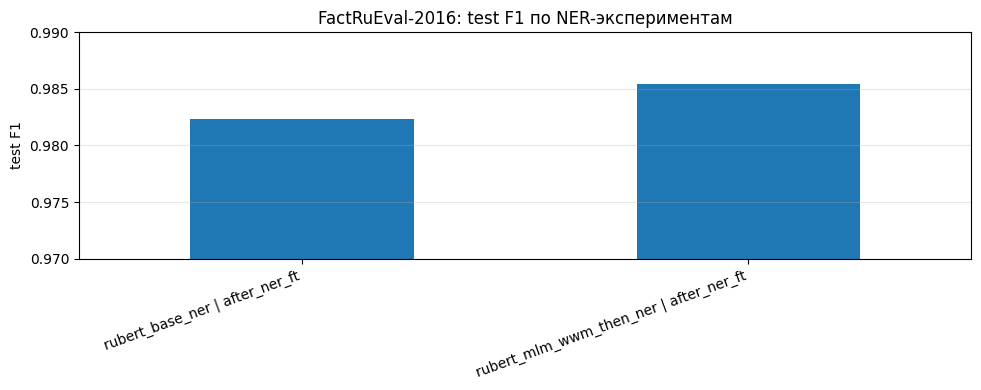

In [68]:
# Сравниваю trained-модели по test F1.
plot_df = results_df[results_df["experiment"].str.contains("after_ner_ft", na=False)].copy()
plot_df = plot_df.dropna(subset=["test_f1"])

if len(plot_df) > 0:
    ax = plot_df.plot(kind="bar", x="experiment", y="test_f1", legend=False, figsize=(10, 4))
    ax.set_title("FactRuEval-2016: test F1 по NER-экспериментам")
    ax.set_xlabel("")
    ax.set_ylabel("test F1")
    ax.set_ylim(0.97, 0.99)
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Нет строк с test_f1 для графика.")

## 8. Пример предсказаний

Кроме чисел полезно глазами посмотреть на несколько примеров: где модель попала в тип сущности, где ошиблась в границах, а где поставила лишнюю сущность.

In [ ]:
def predict_tags_for_example(trainer, split="test", idx=0):
    example = ds[split][idx]
    encoded = tokenizer(
        example["tokens"],
        is_split_into_words=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )

    word_ids = encoded.word_ids(batch_index=0)
    model_inputs = {k: v.to(trainer.model.device) for k, v in encoded.items()}
    with torch.no_grad():
        logits = trainer.model(**model_inputs).logits[0].detach().cpu().numpy()

    pred_ids = logits.argmax(axis=-1)

    rows = []
    seen = set()
    for token_idx, word_idx in enumerate(word_ids):
        if word_idx is None or word_idx in seen:
            continue
        seen.add(word_idx)
        rows.append({
            "token": example["tokens"][word_idx],
            "gold": example["ner_tags"][word_idx],
            "pred": id2label[int(pred_ids[token_idx])],
        })
    return pd.DataFrame(rows)

# Пример разметки для лучшего запуска по test F1.
trained_rows = results_df[results_df["experiment"].str.contains("after_ner_ft", na=False)].dropna(subset=["test_f1"])
if len(trained_rows) > 0:
    best_exp = trained_rows.sort_values("test_f1", ascending=False).iloc[0]["experiment"]
    best_run_name = best_exp.split(" | ")[0]
    print("Best run:", best_run_name)
    display(predict_tags_for_example(trained_trainers[best_run_name], split="test", idx=0).head(80))

Best run: rubert_mlm_wwm_then_ner


,token,gold,pred
0,Тогда,O,O
1,замешанные,O,O
2,в,O,O
3,скандале,O,O
4,прокуроры,O,O
5,отделались,O,O
6,выговорами,O,O
7,и,O,O
8,благополучно,O,O
9,вернулись,O,O


In [ ]:
def find_example_with_entities(split="test"):
    for idx, tags in enumerate(ds[split]["ner_tags"]):
        if any(tag != "O" for tag in tags):
            return idx
    return 0


# Пример разметки для лучшего запуска по test F1.
trained_rows = results_df[
    results_df["experiment"].str.contains("after_ner_ft", na=False)
].dropna(subset=["test_f1"])

if len(trained_rows) > 0:
    best_exp = trained_rows.sort_values("test_f1", ascending=False).iloc[0]["experiment"]
    best_run_name = best_exp.split(" | ")[0]
    example_idx = find_example_with_entities(split="test")

    print("Best run:", best_run_name)
    print("Example idx:", example_idx)

    display(
        predict_tags_for_example(
            trained_trainers[best_run_name],
            split="test",
            idx=example_idx,
        ).head(120)
    )

Best run: rubert_mlm_wwm_then_ner
Example idx: 1


,token,gold,pred
0,Символичным,O,O
1,назвал,O,O
2,председатель,O,O
3,РФМ,B-ORG,B-ORG
4,",",O,O
5,депутат,O,O
6,Государственной,B-ORG,B-ORG
7,думы,I-ORG,I-ORG
8,РФ,B-LOC,B-LOC
9,Леонид,B-PER,B-PER


## 9. Выводы по результатам

In [71]:
def make_conclusion(results_df):
    lines = []
    lines.append("Выводы по экспериментам:\n")

    before = results_df[results_df["experiment"].str.contains("before_ft_random_head", na=False)]
    trained = results_df[results_df["experiment"].str.contains("after_ner_ft", na=False)].dropna(subset=["test_f1"])

    if len(before) > 0:
        b = before.iloc[0]
        lines.append(
            f"1. До supervised fine-tuning качество ожидаемо низкое: "
            f"test F1 = {b.get('f1', float('nan')):.4f}. "
            "Это объясняется тем, что NER-классификатор инициализирован случайно, "
            "хотя сам RuBERT-энкодер уже предобучен."
        )

    if len(trained) > 0:
        base = trained[trained["experiment"].str.startswith("rubert_base_ner")]
        if len(base) > 0:
            r = base.iloc[0]
            lines.append(
                f"2. После fine-tuning на train-части FactRuEval модель резко улучшает качество: "
                f"test precision = {r['test_precision']:.4f}, "
                f"test recall = {r['test_recall']:.4f}, "
                f"test F1 = {r['test_f1']:.4f}."
            )

        mlm = trained[trained["experiment"].str.startswith("rubert_mlm_wwm_then_ner")]
        if len(base) > 0 and len(mlm) > 0:
            base_f1 = float(base.iloc[0]["test_f1"])
            mlm_f1 = float(mlm.iloc[0]["test_f1"])
            delta = mlm_f1 - base_f1
            sign = "выше" if delta > 0 else "ниже"
            lines.append(
                f"3. Подход MLM + Whole Word Mask дал test F1 = {mlm_f1:.4f}, "
                f"что на {abs(delta):.4f} {sign} базового NER fine-tuning. "
                "Даже если прирост небольшой, эксперимент полезен: он проверяет гипотезу "
                "о domain-adaptive pretraining на том же новостном корпусе."
            )

        best = trained.sort_values("test_f1", ascending=False).iloc[0]
        lines.append(
            f"4. Лучший запуск по test F1: {best['experiment']} "
            f"с test F1 = {best['test_f1']:.4f}."
        )

    lines.append(
        "5. Что можно улучшить дальше: подобрать learning rate и batch size, "
        "проверить label_all_tokens=True, увеличить число MLM-эпох, "
        "добавить CRF-голову или использовать синтетическую разметку 10k+ новостных текстов "
        "сильной русскоязычной NER-моделью."
    )

    return "\n\n".join(lines)

print(make_conclusion(results_df))

Выводы по экспериментам:


1. До supervised fine-tuning качество ожидаемо низкое: test F1 = 0.0232. Это объясняется тем, что NER-классификатор инициализирован случайно, хотя сам RuBERT-энкодер уже предобучен.

2. После fine-tuning на train-части FactRuEval модель резко улучшает качество: test precision = 0.9785, test recall = 0.9863, test F1 = 0.9824.

3. Подход MLM + Whole Word Mask дал test F1 = 0.9854, что на 0.0031 выше базового NER fine-tuning. Даже если прирост небольшой, эксперимент полезен: он проверяет гипотезу о domain-adaptive pretraining на том же новостном корпусе.

4. Лучший запуск по test F1: rubert_mlm_wwm_then_ner | after_ner_ft с test F1 = 0.9854.

5. Что можно улучшить дальше: подобрать learning rate и batch size, проверить label_all_tokens=True, увеличить число MLM-эпох, добавить CRF-голову или использовать синтетическую разметку 10k+ новостных текстов сильной русскоязычной NER-моделью.
